<a href="https://colab.research.google.com/github/atharvsalokhe30/Deep_Learning-_project_practice/blob/main/NLP_Named_Entity_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import string
import spacy

from matplotlib.pyplot import imread
from matplotlib import pyplot as plt
from wordcloud import WordCloud
%matplotlib inline

In [ ]:
book=pd.read_csv("apple.txt",on_bad_lines='skip')
book

,x
0,It's amazing..... battery last around 10 -12 h...
1,Finally a MacBook possession. Got it in 50k in...
2,Best Laptop under 60k. If you don't want any a...
3,Pros:1. Light weight and super fast response t...
4,""""
5,I am very upset about the product as I checked...
6,Reason for 1 star is I ot an defective piece. ...
7,Got the Apple Macbook air on amazon discount s...
8,White line coming on screen in just three mont...
9,"Bought this product recently on 5 April, was w..."


In [ ]:
book = [x.strip() for x in book.x]
book = [x for x in book if x]
book[0:10]

["It's amazing..... battery last around 10 -12 hrs.....best laptop for students and coders",
 "Finally a MacBook possession. Got it in 50k in Diwali sale. Technically good laptop.Good News.luxury product, niche technology, good battery life, reliable machine (other laptops crash and become defunct in 6-10 years), no anti-virus required, security of data and transactions much better. Terrific sense of possession & pride.Bad News. Problems will be there if you are switching from windows based system - very less space in hard disk, no CD drive, inability to transfer data from Mac to your existing external hard disc unless you format it, apps are mostly paid and re unreasonably expensive (no free apps which are available otherwise on google play store, even the angry bird costs Rs 400 !!), all printers are not compatible (e.g. the most economical MFD laser printer RICOH SP 111 can't be used), huge compatibility issues with Pages (MS Word) and Keynote (powerpoint) unless you master it by wo

In [ ]:

nlp = spacy.load('en_core_web_sm')

nlp

In [ ]:
one_block = book[10]
doc_block = nlp(one_block)
spacy.displacy.render(doc_block, style='ent', jupyter=True)

In [ ]:
one_block

"Hi, Think thousand time before buying. One calm night i was cuddling in jaipuri blanket while enjoying youtube on this expensive machine. Cold night and little excitement created electrostatic charge which spike though spaceBar button. that's how it went to deep sleep forever. Nothing can bring it back and i am in no mood in spending another fortune on this machine. Apple, of you (i)care, this is the least of security feature included in all electronic devices. And the best part, it was a week after Warranty expiration date."

In [ ]:
for token in doc_block[0:20]:
    print(token, token.pos_)

Hi INTJ
, PUNCT
Think VERB
thousand NUM
time NOUN
before ADP
buying VERB
. PUNCT
One NUM
calm ADJ
night NOUN
i PRON
was AUX
cuddling VERB
in ADP
jaipuri PROPN
blanket NOUN
while SCONJ
enjoying VERB
youtube NOUN


In [ ]:
nouns_verbs = [token.text for token in doc_block if token.pos_ in ('NOUN', 'VERB')]
print(nouns_verbs[5:25])

['blanket', 'enjoying', 'youtube', 'machine', 'night', 'excitement', 'created', 'charge', 'spike', 'button', 'went', 'sleep', 'bring', 'mood', 'spending', 'fortune', 'machine', 'security', 'feature', 'included']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(nouns_verbs)
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
wf_df = pd.DataFrame(words_freq)
wf_df.columns = ['word', 'count']
wf_df[0:10]

,word,count
0,night,2
1,machine,2
2,think,1
3,time,1
4,buying,1
5,cuddling,1
6,blanket,1
7,enjoying,1
8,youtube,1
9,excitement,1


<Axes: title={'center': 'Top verbs and nouns'}, xlabel='word'>

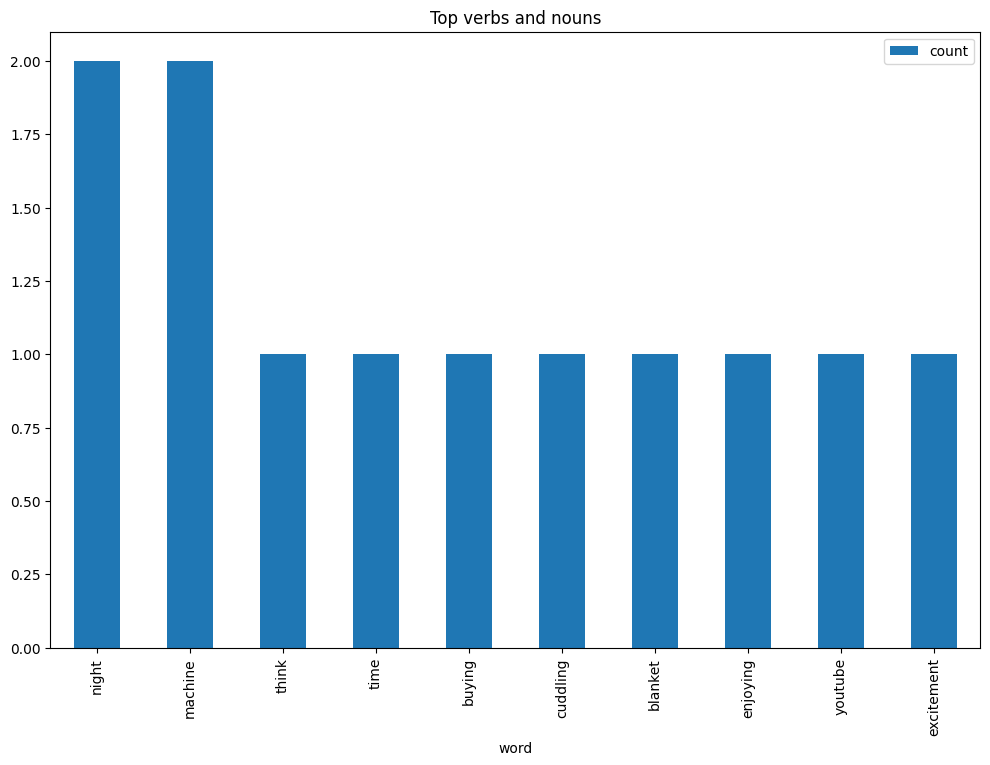

In [ ]:
wf_df[0:10].plot.bar(x='word', figsize=(12,8), title='Top verbs and nouns')